# RadIAnce: Parametric Roof Irradiance Emulation Framework

In this notebook, you will develop an emulator for the annual irradiance and surface area of a parametric roof. The roof geometry is characterized by eight predefined geometric parameters. A computational model has been used to evaluate the yearly irradiance on a mesh discretization of the reconstructed roof; the outputs may therefore be affected by numerical errors.
The goal is to enable efficient solar potential assessment for energy systems analysis and design optimization.

Using Monte Carlo sampling, a dataset has been constructed consisting of 20000 parameter instances and their corresponding two-dimensional outputs. The data are provided in the file `SCTdata20K.csv`.

Note that the ranges of the eight parameters are defined in the following array:

In [2]:
import numpy as np
ranges = np.array([
    [0,5],  #p1
    [0,10], #p2
    [0,5],  #p3
    [0,4],  #p4
    [0,4],  #p5
    [0,4],  #p6
    [3,13], #p7
    [1,7],  #p8
])

## Load data

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression

data = np.genfromtxt('SCTdata20K.csv', delimiter=';', skip_header = 0)
print(data.shape)

(20000, 10)


In [10]:
num_params = 8
num_output = 2
num_samples = 20000

# num_samples = data.shape[0]

params = data[:num_samples,:num_params]
output = data[:num_samples,num_params:]

output[:,1] = output[:,1] * 1e3 # convert to MWh/year

label_params = [f'p{p+1}' for p in range(num_params)]
label_output = ['area [m^2]', 'radiation [MWh/year]']

## Data visualization

Histograms showing the distribution of the two outputs (area and radiation)

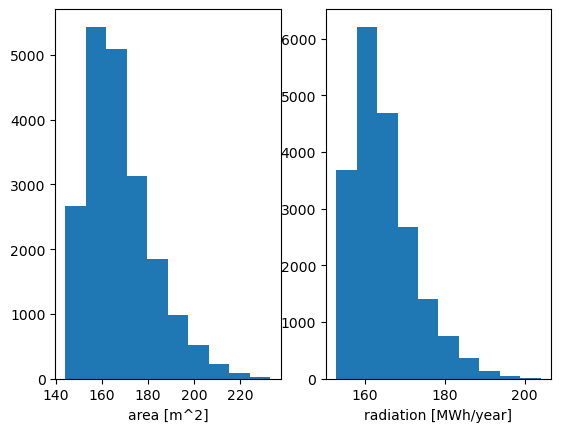

In [11]:
fig, axs = plt.subplots(1,num_output)
for o in range(num_output):
    axs[o].hist(output[:,o])
    axs[o].set_xlabel(label_output[o])

Scatterplot to show the correlation between the two outputs (area and radiation)

Text(0, 0.5, 'radiation [MWh/year]')

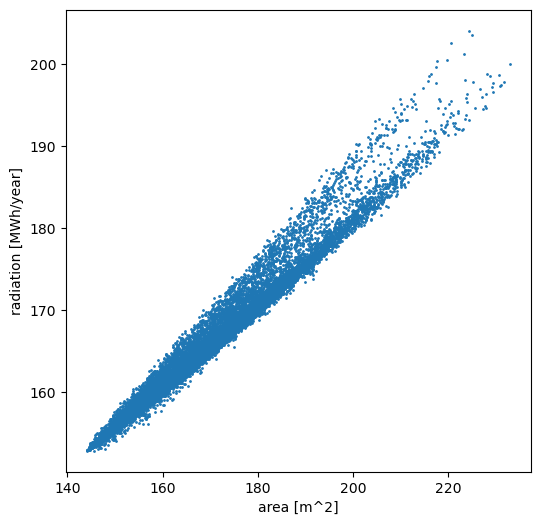

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.scatter(output[:,0], output[:,1], s = 1)
ax.set_xlabel(label_output[0])
ax.set_ylabel(label_output[1])

# Signature of the function

You are required to implement the function `checkpoint_implementation(params)`, which implement the surrogate model. 

The input argument params is a NumPy array of shape (num_samples, 8), where each row represents a roof configuration defined by the eight geometric parameters. The function must work for an arbitrary number of samples.

The function should return a NumPy array predicted_output with shape (num_samples, 2), matching the structure of the reference outputs provided in the dataset. The second column must contain the predicted annual irradiance, and the first column must contain the predicted roof surface area. 

In [13]:
# Addestramento del modello di regressione lineare multivariata
model = MultiOutputRegressor(LinearRegression())
model.fit(params, output)

def checkpoint_implementation(params):
    #
    # predicted_output must be a numpy array with the same with shape (num samples,2)

    predicted_output = model.predict(params)
    
    return predicted_output

## Test del modello

In [15]:
# Test sulla totalità del dataset
predictions = checkpoint_implementation(params)

print("Predizioni sui primi 5 campioni:")
print("Predetti:\n", predictions[:5])
print("\nReali:\n", output[:5])

# Calcola l'errore medio (MSE - Mean Squared Error)
from sklearn.metrics import mean_squared_error, r2_score

mse_area = mean_squared_error(output[:, 0], predictions[:, 0])
mse_radiation = mean_squared_error(output[:, 1], predictions[:, 1])
r2_area = r2_score(output[:, 0], predictions[:, 0])
r2_radiation = r2_score(output[:, 1], predictions[:, 1])

print(f"Superficie (area):")
print(f"  MSE: {mse_area:.6f}")
print(f"  R²: {r2_area:.6f}")
print(f"\nIrradianza (radiation):")
print(f"  MSE: {mse_radiation:.6f}")
print(f"  R²: {r2_radiation:.6f}")

Predizioni sui primi 5 campioni:
Predetti:
 [[168.73316476 164.5926398 ]
 [168.96054596 165.90926326]
 [162.27814593 161.72538699]
 [146.12094785 152.62567262]
 [162.40660775 161.78405329]]

Reali:
 [[160.838963 160.68    ]
 [161.405398 160.532   ]
 [161.027721 160.701   ]
 [154.611087 158.457   ]
 [160.530018 161.155   ]]
Superficie (area):
  MSE: 52.025959
  R²: 0.746237

Irradianza (radiation):
  MSE: 16.443098
  R²: 0.727656
